<div style="display: flex; flex-direction: row; justify-content: space-between; font-weight: bold; text-decoration: none">
<a href="02_exploratory_data_analysis.ipynb"><<< Back to Exploratory Data Analysis</a>
<a href="../README.md"> Go to README File (Conclusions) >>> </a>
</div>

In [1]:
import duckdb 
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

## Electric Vehicle Insights and Visualizations

### Introduction of Analysis and Business Context

### Objectives / Questions

These are the same questions from the previous section, but I decided to group them by common topic so they can be answered with similar queries. 

**Brand and Model Dominance**
1) What are the top EV brands across the United States?
2) Which models and model years are the most popular and least popular of EV brands?
3) What are the top ten most popular makes of cars? Of those ten, what are the distribution of models by make?
    
    **Segmented by Electric Vehicle Type**
    1) What are the top five most popular cars by Electric Vehicle Type?
    2) What is the distribution of Electric Vehicle Type cars by year? 
    3) What are the most popular and least popular brands and models in each county?

**Geographic Relevance**
1) Which counties and cities have the most EVs?
2) Which states and counties have the highest concentration of top EV brands?

    **Segmented by Electric Vehicle Type**
    1) Which are the top five counties or cities in terms of each type Electric Vehicle type?
    2) Which counties and of those counties, which cities have the most electric cars split by Electric Vehicle type?
    3) How many cars are in each city by Electric Vehicle Type?

**Range and Capability**

1) Which brands and models have the highest Electric Range and the lowest?
2) What are the max and min Electric ranges of both Electric Vehicle types?
3) How does Electric Range change by year and Electruc Vehicle Type?

**Historical Adoption Trends**

1) How has the number of Battery Electric and Plug-In Hybrid changed over the years?

### Loading Cleaned Data

In [2]:
df = pd.read_csv("../data/cleaned/data_wo_fuel.csv")
df.head()

,County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligible?,Electric Range (in Miles),Vehicle Location,Electric Utility
0,Stevens,Colville,WA,99114.0,2012,NISSAN,LEAF,Battery Electric (BEV),True,73.0,POINT (-117.90454 48.54657),AVISTA CORP
1,Yakima,Yakima,WA,98903.0,2023,SUBARU,SOLTERRA,Battery Electric (BEV),NaN,NaN,POINT (-120.71847 46.55029),PACIFICORP
2,King,Seattle,WA,98122.0,2018,NISSAN,LEAF,Battery Electric (BEV),True,151.0,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)
3,Kitsap,Poulsbo,WA,98370.0,2025,BMW,X5,Plug-in Hybrid (PHEV),True,40.0,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC
4,Thurston,Yelm,WA,98597.0,2015,FIAT,500,Battery Electric (BEV),True,87.0,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC


### Answering Questions: Querying and Visual Analysis

#### Brand Dominance Questions

1) What are the top 5 EV brands across the United States?

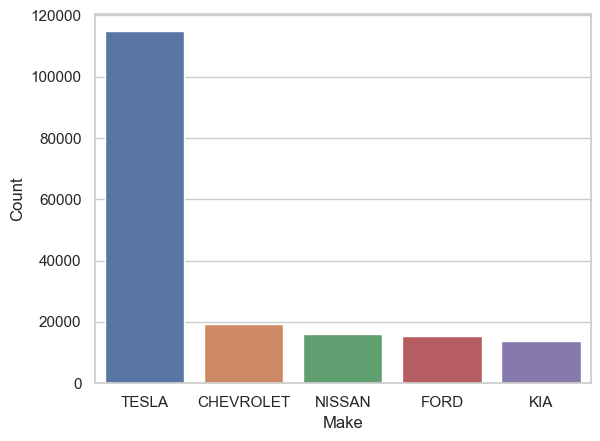

In [3]:
results = duckdb.sql("""
                     SELECT Make, COUNT(Make) AS Count FROM df
                     GROUP BY Make
                     ORDER BY COUNT(Make) DESC
                     LIMIT 5
                     """).df()

sns.set_theme(style='whitegrid')
sns.barplot(results, x='Make', y='Count', hue='Make')
plt.show()

2) Of those five most and least popular brands, what are the distribution of models by make?

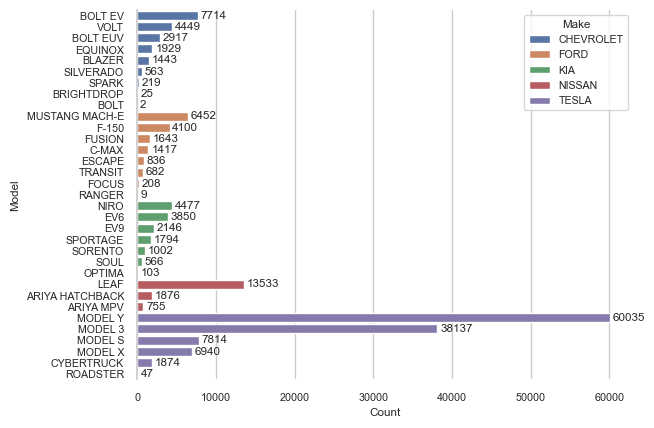

In [4]:
dist_most = duckdb.sql("""
                    SELECT Make, Model, COUNT(Model) as Count from df
                    WHERE Make IN('TESLA', 'CHEVROLET', 'NISSAN', 'FORD', 'KIA')
                    GROUP BY Make, Model
                    ORDER BY Make, Count DESC
                     """).df()

# sets the theme with a white grid, and makes the font 30% smaller.
sns.set_theme(style='whitegrid', font_scale=0.7)

# plotting the horizontal bar chart
plot = sns.barplot(dist_most, x='Count', y='Model', hue='Make')

# adding labels to each bar, more info found here: https://www.geeksforgeeks.org/python/how-to-show-values-on-seaborn-barplot/
for container in plot.containers:
    plot.bar_label(container, padding=2)

# removing the top, left, and bottom edges of the graph
sns.despine(bottom=True)
plt.show()


3) Which models have been the 10 most popular and least popular of EV Makes and Models across the United States?

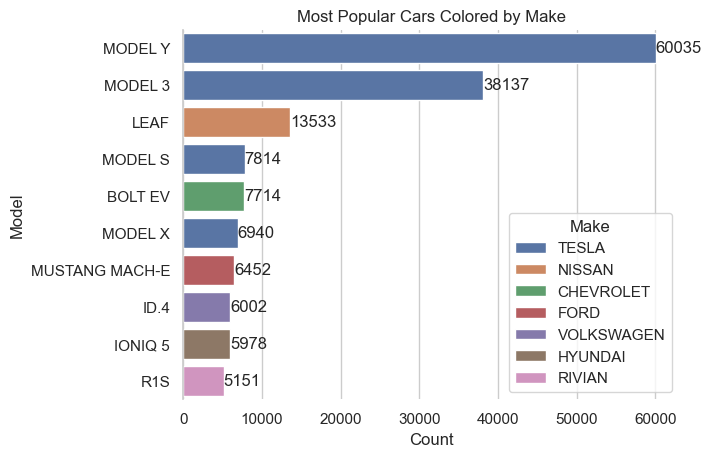

In [5]:
most_pop = duckdb.sql("""
                     SELECT Make, Model, COUNT(Model) AS Count FROM df
                     GROUP BY Make, Model
                     ORDER BY Count DESC
                     LIMIT 10
                     """).df()

sns.reset_defaults()
sns.set_theme(style="whitegrid")
plot = sns.barplot(most_pop, x='Count', y='Model', hue='Make')
for container in plot.containers:
    plot.bar_label(container)

sns.despine(bottom=True)
plot.set_title('Most Popular Cars Colored by Make')
plt.show()


In [6]:
least_pop = duckdb.sql("""
                     SELECT Make, Model, COUNT(Model) AS Count FROM df
                     GROUP BY Make, Model
                     ORDER BY COUNT(Model) ASC
                     LIMIT 10
                     """).df()

least_pop

,Make,Model,Count
0,RIVIAN,RCV,1
1,MASERATI,GRANCABRIO,1
2,WHEEGO ELECTRIC CARS,WHEEGO,2
3,CHEVROLET,BOLT,2
4,PORSCHE,918,2
5,BENTLEY,BENTAYGA,3
6,BENTLEY,CONTINENTAL,3
7,AZURE DYNAMICS,TRANSIT CONNECT ELECTRIC,3
8,VINFAST,VF 8,4
9,MERCEDES-BENZ,SL-CLASS,4


##### Segmentation Questions by Electric Vehicle Type

1) What are the top five most popular cars by Electric Vehicle Type?

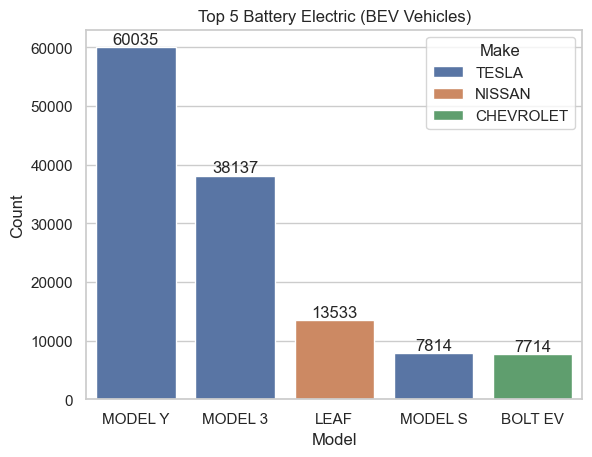

In [7]:
most_pop_battery_electric = duckdb.sql("""
                    SELECT Make, Model, COUNT(Model) AS Count FROM df
                    WHERE "Electric Vehicle Type" = 'Battery Electric (BEV)'
                    GROUP BY Make, Model, "Electric Vehicle Type"
                    ORDER BY Count DESC
                    LIMIT 5
                    """).df()
plot = sns.barplot(most_pop_battery_electric, x='Model', y='Count', hue='Make')
for container in plot.containers:
    plot.bar_label(container)
plot.set_title('Top 5 Battery Electric (BEV Vehicles)')
plt.show()

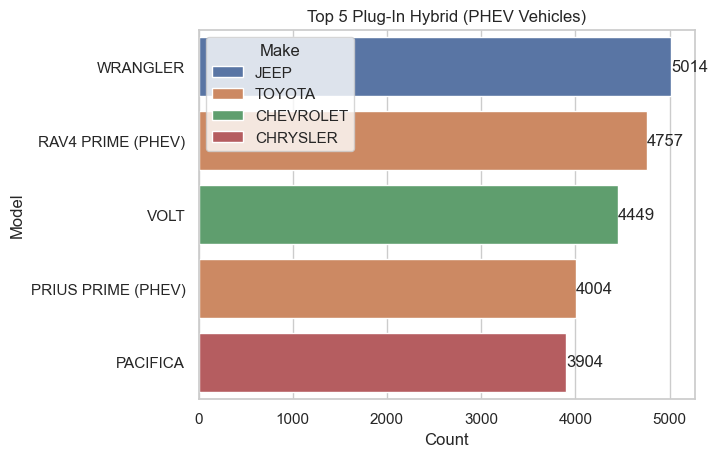

In [8]:
most_pop_plugin_hybrid = duckdb.sql("""
                    SELECT Make, Model, COUNT(Model) AS Count FROM df
                    WHERE "Electric Vehicle Type" = 'Plug-in Hybrid (PHEV)'
                    GROUP BY Make, Model, "Electric Vehicle Type"
                    ORDER BY Count DESC
                    LIMIT 5
                    """).df()
plot = sns.barplot(most_pop_plugin_hybrid, x='Count', y='Model', hue='Make')
for container in plot.containers:
    plot.bar_label(container)
plot.set_title('Top 5 Plug-In Hybrid (PHEV Vehicles)')
plt.show()

2) What is the distribution of Electric Vehicle Type cars by year? 

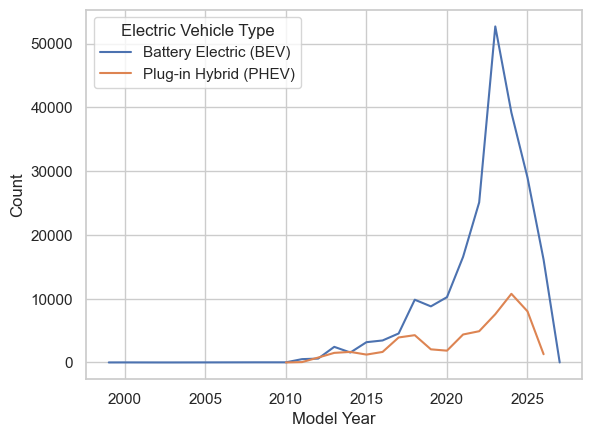

In [9]:
yearly_dist = duckdb.sql("""
                    SELECT "Electric Vehicle Type", "Model Year", COUNT(Model) AS Count FROM df
                    GROUP BY "Electric Vehicle Type", "Model Year"
                    ORDER BY Count DESC
                    """).df()
sns.lineplot(yearly_dist, x="Model Year", y='Count', hue="Electric Vehicle Type")
plt.show()

4) What are the counties and states with the most EVs?

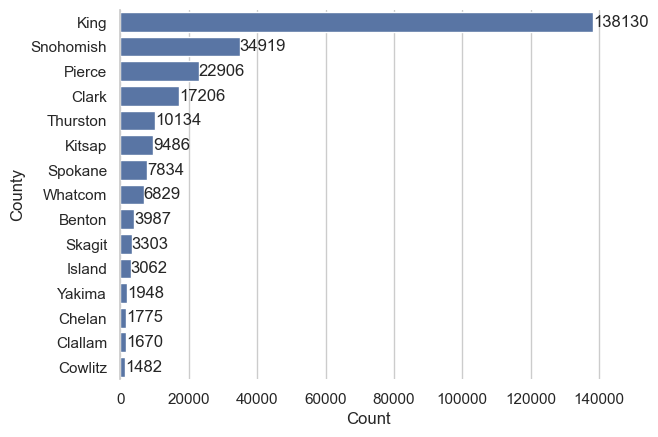

In [10]:
pop_county = duckdb.sql("""
                    SELECT County, State, COUNT(County) AS Count FROM df
                    GROUP BY County, State
                    ORDER BY Count DESC
                    LIMIT 15
                    """).df()
plot = sns.barplot(pop_county, x="Count", y="County")
for container in plot.containers:
    plot.bar_label(container)
sns.despine(bottom=True)
plt.show()

3) What are the top 15 brands (split by Electric Vehicle Type) in the top five counties you found above that are not Teslas (since new Teslas are only sold in official showrooms)?

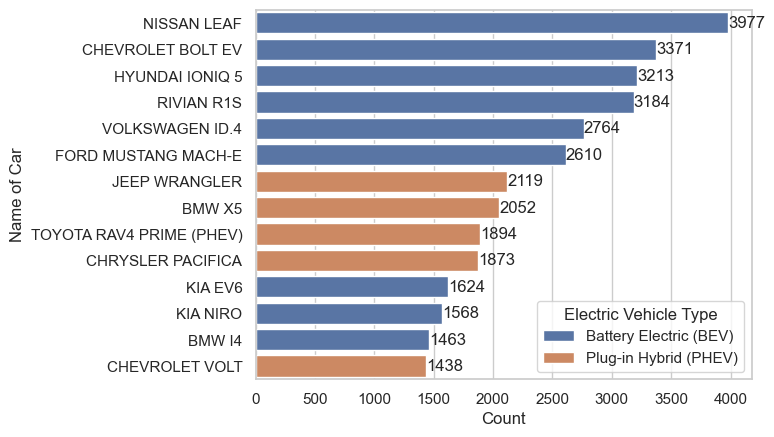

In [11]:
pop_brands = duckdb.sql("""
                    SELECT County, Make, Model, "Electric Vehicle Type", COUNT(Model) AS Count FROM df
                    WHERE County in ('King', 'Snohomish', 'Pierce', 'Clark', 'Thurston') AND Make <> 'TESLA'
                    GROUP BY Make, Model, "Electric Vehicle Type", County
                    ORDER BY Count DESC
                    LIMIT 15
                    """).df()
pop_brands["Name of Car"] = pop_brands["Make"] + " " + pop_brands["Model"]
plot = sns.barplot(pop_brands, x="Count", y="Name of Car", hue="Electric Vehicle Type", errorbar=None)
for container in plot.containers:
    plot.bar_label(container)
plt.show()

In the top ten counties, how many are BEVs vs PHEVs?

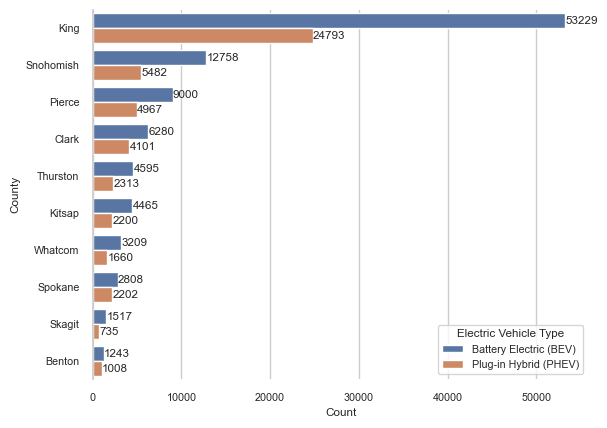

In [12]:
ev_type_county = duckdb.sql("""
                    SELECT County, "Electric Vehicle Type", COUNT("Electric Vehicle Type") AS Count FROM df
                    WHERE County in ('King', 'Snohomish', 'Pierce', 'Clark', 'Thurston', 'Kitsap', 'Spokane', 'Whatcom', 'Benton', 'Skagit') AND Make <> 'TESLA'
                    GROUP BY County, "Electric Vehicle Type"
                    ORDER BY Count DESC
                    """).df()

sns.set_theme(style="whitegrid", font_scale=0.7)
plot = sns.barplot(ev_type_county, x='Count', y='County', hue="Electric Vehicle Type")
for container in plot.containers:
    plot.bar_label(container, padding=0.3)
sns.despine(bottom=True)
plt.show()

#### Geographic Relevance Questions

1) Which counties and cities have the most EVs?

2) Which counties and cities have the highest concentration of the top five EVs in both PHEV and BEV Electric Type Vehicles (brands were found in question 1 of the previous segmentation section)?

##### Segmentation Questions by Electric Vehicle Type

1) Which are the top five counties or cities in terms of each type Electric Vehicle type?

2) Which counties and of those counties, which cities have the most electric cars split by Electric Vehicle type?

3) How many cars are in each city by Electric Vehicle Type?

#### Range and Capability Questions

1) Which brands and models have the highest Electric Range and the lowest?

2) What are the max and min Electric ranges of both Electric Vehicle types?

3) How does Electric Range change by year and Electruc Vehicle Type?

#### Historical Adoption Trends Questions

1) How has the number of Battery Electric and Plug-In Hybrid changed over the years?

2) What is the trend of most popular and least popular Makes over the years?

## Key Insights

## Conclusions and Next Steps

results = duckdb.sql("""
                     SELECT * FROM df
                     WHERE Make = 'NISSAN' AND "Electric Vehicle Type" = 'Battery Electric (BEV)'
                     """).df()
results

<div style="display: flex; flex-direction: row; justify-content: space-between; font-weight: bold; text-decoration: none">
<a href="02_exploratory_data_analysis.ipynb"><<< Back to Exploratory Data Analysis</a>
<a href="../README.md"> Go to README File (Conclusions) >>> </a>
</div>